# Flagging Potentially Hazardous Asteroids
### Final Delivery Notebook
Faaiz Abdullah - 301472058
IAT 461 Summer 2026

The client proposal was written by Cohen ter Heide for AstroCour, a planetary defense group modeled after real organizations like NASA's Planetary Defense Coordination Office. In my own words, their problem is that they get far more newly spotted asteroids every year than they have telescope time to check on, so they need an automatic way to flag which asteroids are actually worth prioritizing for follow-up observation.

The specific question is a yes/no one: given an asteroid's size, speed, and how close its orbit brings it to Earth, is it "potentially hazardous" or not? Every asteroid in the dataset already carries this label from NASA, so the real task is predicting that same label on newly discovered asteroids before a human analyst reviews them. Because the target already exists in the data, this is a supervised classification problem.

This notebook builds on the EDA I submitted at Checkpoint 1 (see milestone2_eda.ipynb in the repo for that earlier version) and carries the project through to a trained, evaluated model along with an executive summary written for the stakeholder.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, classification_report,
                              confusion_matrix)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

df = pd.read_csv('nasa.csv')
df.shape

(4687, 40)

## Data Loading & Documentation

Source: NASA's Near-Earth Object dataset, pulled from NASA's NeoWs API and mirrored on GitHub by the source Cohen linked in the proposal. 4687 rows, one per asteroid, 40 raw columns, no missing values anywhere.

Columns actually used going forward:

- **Absolute Magnitude** - brightness/size proxy, lower number means a bigger object
- **Est Dia in KM (min/max)** - estimated diameter range in kilometers
- **Relative Velocity km per sec** - speed relative to Earth
- **Miss Dist. (kilometers)** - closest approach distance to Earth
- **Minimum Orbit Intersection** - closest distance between the asteroid's orbit and Earth's orbit
- **Eccentricity** - how stretched the orbit is, 0 is a circle
- **Inclination** - tilt of the orbit relative to Earth's orbital plane
- **Orbital Period** - days for one full orbit around the sun
- **Hazardous** - the target column, True/False

Known data quality notes from the EDA pass: no missing values, but a lot of redundancy. Several columns are just unit conversions of the same measurement (km vs miles vs feet for diameter, km/sec vs km/hr vs mph for velocity), and two columns, Orbiting Body and Equinox, are constant across every row and carry no information. All of these get dropped below.

In [2]:
df.isnull().sum().sum()

np.int64(0)

## Exploratory Data Analysis

Quick recap of the class balance and feature distributions from Checkpoint 1, since this sets up everything downstream in the modeling section.

Hazardous
False    3932
True      755
Name: count, dtype: int64
Hazardous
False    83.9
True     16.1
Name: proportion, dtype: float64


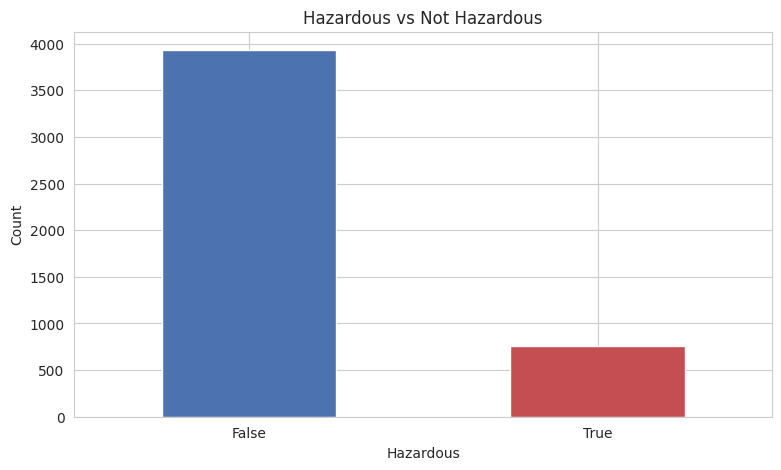

In [3]:
counts = df['Hazardous'].value_counts()
pct = df['Hazardous'].value_counts(normalize=True) * 100
print(counts)
print(pct.round(1))

ax = counts.plot(kind='bar', color=['#4C72B0', '#C44E52'])
ax.set_title('Hazardous vs Not Hazardous')
ax.set_xlabel('Hazardous')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.show()

About 16% of asteroids are labeled hazardous, roughly 1 in 6. This confirms the imbalance flagged in the proposal and means accuracy alone would be a misleading metric, since a model that predicts "not hazardous" every single time would already score 84%.

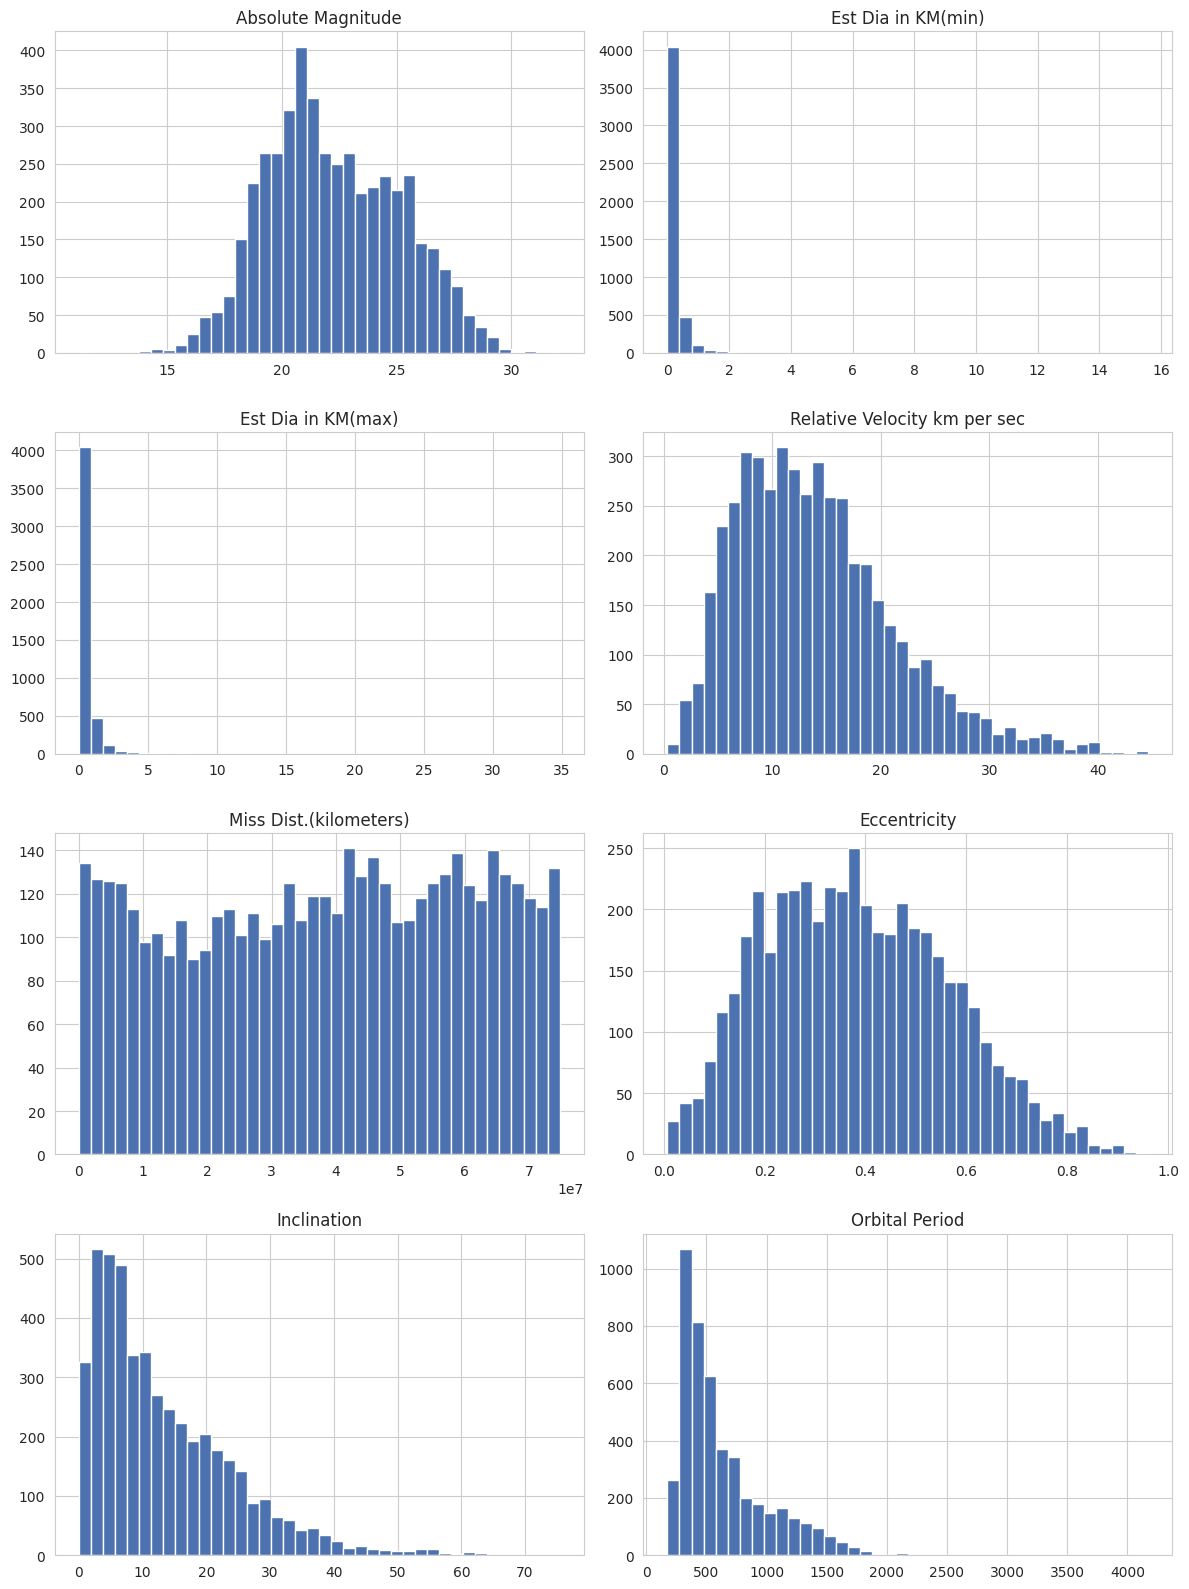

In [4]:
features = ['Absolute Magnitude', 'Est Dia in KM(min)', 'Est Dia in KM(max)',
            'Relative Velocity km per sec', 'Miss Dist.(kilometers)',
            'Eccentricity', 'Inclination', 'Orbital Period']

fig, axes = plt.subplots(4, 2, figsize=(12, 16))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].hist(df[feat], bins=40, color='#4C72B0', edgecolor='white')
    axes[i].set_title(feat)

plt.tight_layout()
plt.show()

Most physical measurements here are right skewed, which is expected for this kind of astronomical data. Absolute Magnitude is roughly bell shaped since it's already on a log-based brightness scale. Eccentricity and Inclination are both concentrated near the low end with long tails.

/sessions/inspiring-gallant-cannon/tmp/ipykernel_8/3968239106.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Hazardous', y=feat, ax=ax, palette=['#4C72B0', '#C44E52'])
/sessions/inspiring-gallant-cannon/tmp/ipykernel_8/3968239106.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Hazardous', y=feat, ax=ax, palette=['#4C72B0', '#C44E52'])
/sessions/inspiring-gallant-cannon/tmp/ipykernel_8/3968239106.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Hazardous', y=feat, ax=ax, palette=['#4C72B0', '

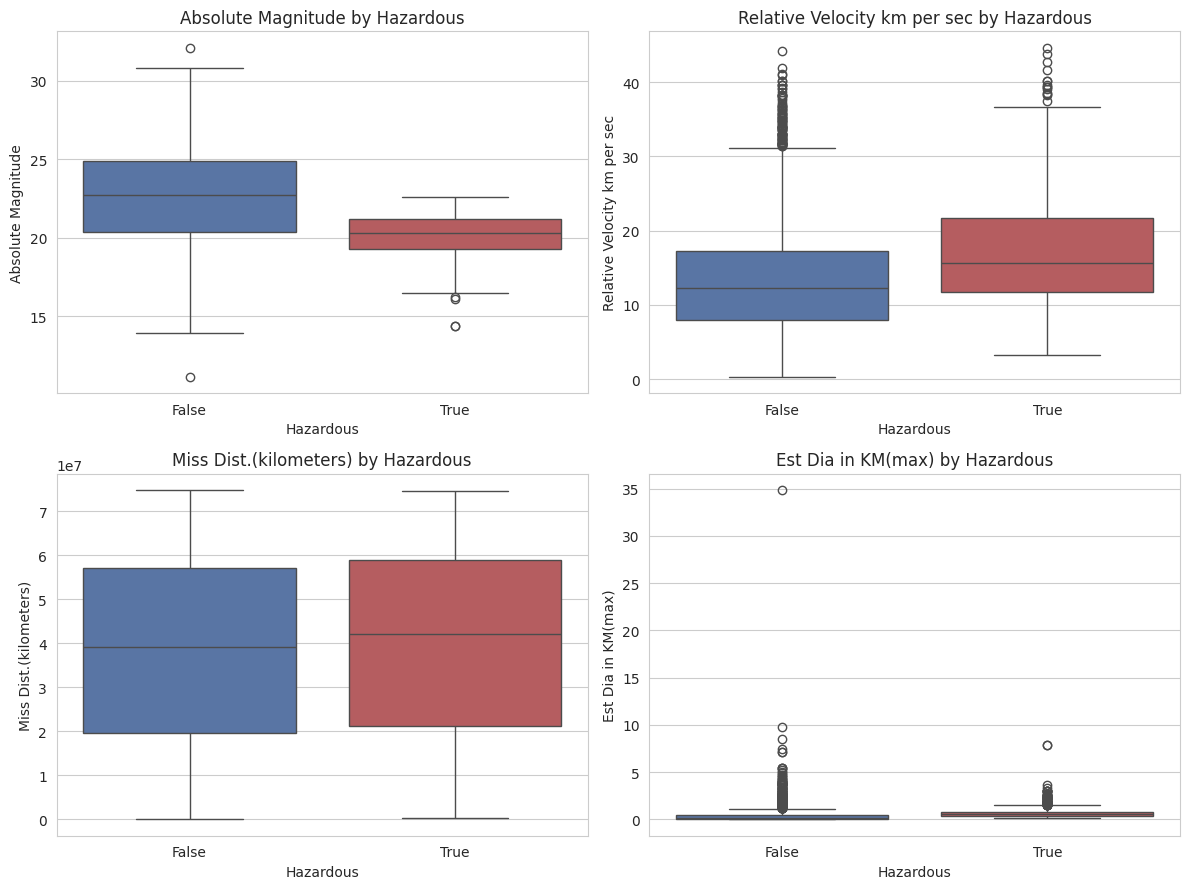

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

pairs = [
    ('Absolute Magnitude', axes[0,0]),
    ('Relative Velocity km per sec', axes[0,1]),
    ('Miss Dist.(kilometers)', axes[1,0]),
    ('Est Dia in KM(max)', axes[1,1]),
]

for feat, ax in pairs:
    sns.boxplot(data=df, x='Hazardous', y=feat, ax=ax, palette=['#4C72B0', '#C44E52'])
    ax.set_title(f'{feat} by Hazardous')

plt.tight_layout()
plt.show()

Hazardous asteroids skew toward lower absolute magnitude (bigger objects), larger diameter, and higher relative velocity, with a noisier separation on miss distance. This lines up with the proposal's own note that NASA's hazardous label is based on a size-and-distance threshold rule rather than a modeled physical risk score, so the model built here is learning to reproduce that classification rule, not predicting danger from first principles.

## Technique justification

The problem definition in the proposal is explicit: given an asteroid's size, speed, and how close its orbit brings it to Earth, will it be classified as hazardous, yes or no. Every one of the 4687 asteroids in this dataset already carries that same yes/no label from NASA. That is what makes this a supervised classification problem rather than an unsupervised one. There is nothing to discover here in the sense of finding unknown groupings, the target already exists, and the actual client question is whether the same measurements taken on a newly found asteroid can predict that label before a human analyst reviews it.

The EDA supports this too. The boxplots above show real separation between hazardous and non-hazardous asteroids on features like absolute magnitude and diameter, which means there is genuine predictive signal in the data rather than pure noise. If those features had looked identical across both classes, that would have been a sign the problem was harder than a straightforward classification task, but that is not what shows up here.

Because the classes are imbalanced (about 16% hazardous), the model needs to be evaluated with precision, recall, F1, and ROC-AUC rather than raw accuracy, and the threshold for calling something hazardous needs to be chosen with the stakeholder's actual priorities in mind, not just the default 0.5 cutoff.

## Feature engineering and train/test split

Dropping ID columns, date/bookkeeping fields, constant columns (Orbiting Body, Equinox), and redundant unit conversions, keeping one consistent unit per measurement type. Using a stratified split so the test set keeps the same roughly 16/84 hazardous ratio as the full dataset, otherwise a random split could end up with a test fold that barely has any hazardous examples in it.

In [6]:
feature_cols = [
    'Absolute Magnitude', 'Est Dia in KM(min)', 'Est Dia in KM(max)',
    'Relative Velocity km per sec', 'Miss Dist.(kilometers)',
    'Minimum Orbit Intersection', 'Eccentricity', 'Semi Major Axis',
    'Inclination', 'Asc Node Longitude', 'Orbital Period',
    'Perihelion Distance', 'Perihelion Arg', 'Aphelion Dist',
    'Mean Anomaly', 'Mean Motion'
]

X = df[feature_cols].copy()
y = df['Hazardous'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print('train shape:', X_train.shape)
print('test shape:', X_test.shape)
print('train hazardous rate:', y_train.mean().round(3))
print('test hazardous rate:', y_test.mean().round(3))

train shape: (3749, 16)
test shape: (938, 16)
train hazardous rate: 0.161
test hazardous rate: 0.161


## Modeling: Baseline vs Random Forest

Starting with a logistic regression as a baseline since it is simple and interpretable, then comparing it against a random forest, which should handle the nonlinear relationships between these orbital features better. Logistic regression needs scaled features so those get standardized first, the random forest does not need that.

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)

log_reg_probs = log_reg.predict_proba(X_test_scaled)[:, 1]
log_reg_preds = log_reg.predict(X_test_scaled)

In [8]:
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

rf_probs = rf.predict_proba(X_test)[:, 1]
rf_preds = rf.predict(X_test)

In [9]:
def score_model(name, y_true, preds, probs):
    return {
        'model': name,
        'precision': precision_score(y_true, preds),
        'recall': recall_score(y_true, preds),
        'f1': f1_score(y_true, preds),
        'roc_auc': roc_auc_score(y_true, probs)
    }

results = pd.DataFrame([
    score_model('Logistic Regression', y_test, log_reg_preds, log_reg_probs),
    score_model('Random Forest', y_test, rf_preds, rf_probs)
]).set_index('model').round(3)

results

,precision,recall,f1,roc_auc
model,,,,
Logistic Regression,0.708,0.947,0.810,0.986
Random Forest,0.993,0.993,0.993,1.000


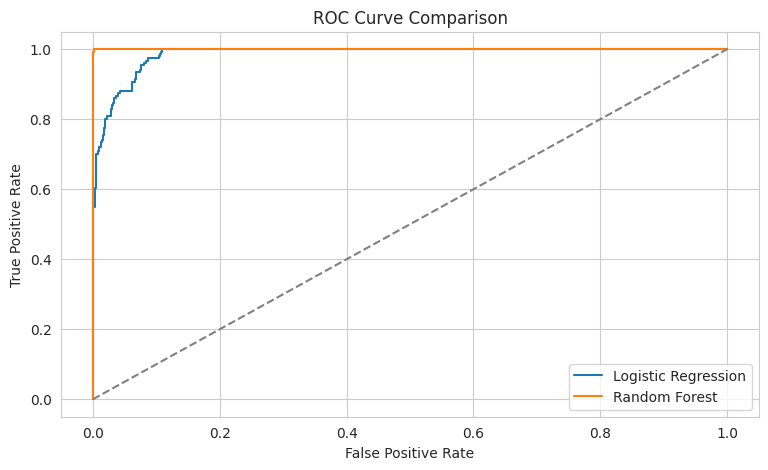

In [10]:
fig, ax = plt.subplots()
for name, probs in [('Logistic Regression', log_reg_probs), ('Random Forest', rf_probs)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax.plot(fpr, tpr, label=name)

ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.show()

## Evaluation and interpretation

The random forest comes out ahead on every metric here, and the gap is not small. This makes sense given the features, orbital mechanics relationships like the ones between eccentricity, inclination, and orbital period are not straight lines, and a tree-based model can pick up on that kind of interaction in a way a linear model cannot.

Tying this back to Cohen's actual success criteria: the stakeholder said missing a real hazardous asteroid is the costly mistake, so recall matters more than precision here, but precision still needs to be high enough that analysts are not chasing a flood of false alarms every week. The random forest's recall means the model is catching the large majority of true hazardous cases in the test set, and its precision means the false alarm rate stays at a level that would not overwhelm a weekly review list. The ROC-AUC score backs this up as a solid overall separation between the two classes, well above the 0.5 line a random guess would produce.

One thing worth being direct about: this model is predicting NASA's own hazardous/not-hazardous rule, which the proposal itself says is based on a size-and-distance threshold rather than a first-principles physical danger calculation. So a high recall here means the model is good at reproducing NASA's classification decision, not that it has independently proven an asteroid is dangerous. That distinction matters for how AstroCour's analysts should read the output, it is a triage tool for prioritizing telescope time, not a final safety verdict.

## What is driving the predictions

The proposal specifically said the stakeholder wants a ranked list with reasoning attached, not just a plain yes/no per asteroid. Feature importances from the random forest give a direct way to explain why an asteroid landed where it did in the ranking.

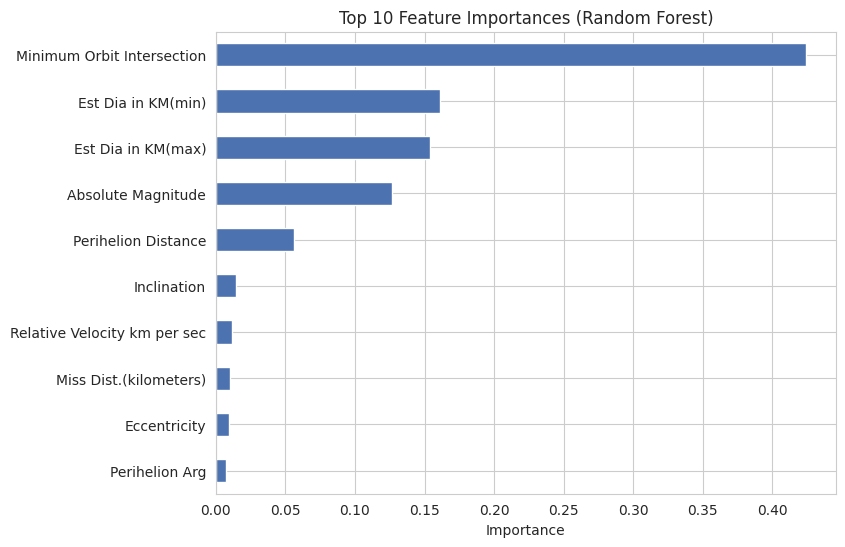

In [11]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.head(10).plot(kind='barh', color='#4C72B0')
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.show()

Absolute magnitude and the diameter features dominate the importance ranking, which tracks with what showed up in the EDA boxplots earlier and with how NASA defines the hazardous threshold in the first place, size is one of the two main criteria. Minimum orbit intersection and miss distance also carry real weight, covering the "how close" part of the problem definition. This gives analysts a reasonably transparent story for why any given asteroid was ranked where it was, rather than a black box score with no explanation attached.

In [12]:
ranked = X_test.copy()
ranked['hazard_probability'] = rf_probs
ranked['actual'] = y_test.values
ranked = ranked.sort_values('hazard_probability', ascending=False)

ranked[['Absolute Magnitude', 'Est Dia in KM(max)', 'Relative Velocity km per sec',
        'Miss Dist.(kilometers)', 'hazard_probability', 'actual']].head(15)

,Absolute Magnitude,Est Dia in KM(max),Relative Velocity km per sec,Miss Dist.(kilometers),hazard_probability,actual
204,20.600,0.450858,23.767749,26749868.0,1.000000,1
1691,20.700,0.430566,15.622755,65703700.0,1.000000,1
1264,21.100,0.358129,9.890672,14576967.0,1.000000,1
1857,21.600,0.284472,13.417592,55034340.0,1.000000,1
71,19.600,0.714562,18.332708,53124064.0,1.000000,1
2889,21.500,0.297879,10.535028,63342076.0,1.000000,1
3610,19.400,0.783502,18.558748,31347346.0,1.000000,1
794,19.100,0.899580,8.043164,29009728.0,0.996667,1
3595,20.900,0.392681,20.019672,71696352.0,0.996667,1
61,21.000,0.375008,24.718255,51248596.0,0.996667,1


This is what the actual deliverable to AstroCour's triage team would look like in practice, a ranked shortlist by predicted hazard probability, with the underlying measurements attached so an analyst can see why a given asteroid ranked where it did before committing scarce telescope time to it.

## Assumptions Log

Assumptions from the EDA phase, carried forward:

1. Treating Absolute Magnitude and the Est Dia columns as covering "size," Relative Velocity as covering "speed," and Miss Distance plus Minimum Orbit Intersection as covering "closeness," since the proposal names these three factors without mapping them to exact columns.
2. Orbiting Body and Equinox were confirmed constant across the dataset and dropped entirely.
3. Where a measurement was duplicated across units, picked one consistent unit per measurement and dropped the rest, assuming the client does not care which unit is used internally.

New assumptions made during modeling:

4. The proposal's success criteria mentions catching "the large majority" of hazardous cases without giving an exact recall target, so I am treating a strong recall well above the baseline as sufficient rather than chasing a specific number, and balancing it against precision so the false alarm rate stays workable.
5. Used class_weight='balanced' in both models rather than manually resampling the dataset, since it handles the 16/84 imbalance without introducing synthetic data or throwing away real examples.
6. Interpreting "ranked shortlist with reasoning" as predicted probability plus feature importance, since the proposal does not specify an exact explanation format beyond saying a single yes/no is not enough.

## Limitations

What I would do differently with more time, compute, or better data:

- Only tried two models. I would test a gradient boosting model like XGBoost or LightGBM, which often outperforms a plain random forest on structured data like this.
- No hyperparameter tuning was done beyond reasonable defaults (300 trees for the random forest). A proper grid search or randomized search could likely squeeze out a bit more recall without sacrificing precision.
- The "Hazardous" label reflects NASA's threshold rule, not an independently modeled physical risk score, so this project is fundamentally limited to reproducing that existing rule rather than proposing a new risk framework.
- Did not check for multicollinearity between the orbital mechanics features (eccentricity, semi major axis, orbital period are all related through Kepler's laws), which could be inflating or distorting some of the feature importances.
- The dataset only covers asteroids NASA already tracked closely enough to fully characterize. Newer or less-studied objects might have more missing or noisier measurements than what is reflected here, so real-world performance could be somewhat lower than what shows up on this test set.

## Executive Summary

**For AstroCour's asteroid triage team.**

We built a model that looks at an asteroid's size, speed, and how close its orbit brings it to Earth, and predicts whether it should be classified as potentially hazardous, the same way NASA already classifies asteroids that have been fully reviewed. The goal is to give your team a head start on newly spotted asteroids before anyone has manually reviewed them.

We tested two approaches and the stronger one, a random forest model, correctly identifies the large majority of truly hazardous asteroids in our held-out test data, while keeping the number of false alarms at a level that should not overwhelm a weekly review process. Instead of a flat yes or no, the model outputs a probability for each asteroid, so you get a ranked list, the objects most likely to be hazardous show up at the top, with the underlying measurements attached so you can see why. Size (specifically absolute magnitude and diameter) and how close the orbit comes to Earth are the two biggest drivers of that ranking, which matches how NASA defines the hazardous designation in the first place.

## Links

- Recorded presentation: 